In [77]:
print(1)

1


In [85]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [86]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler

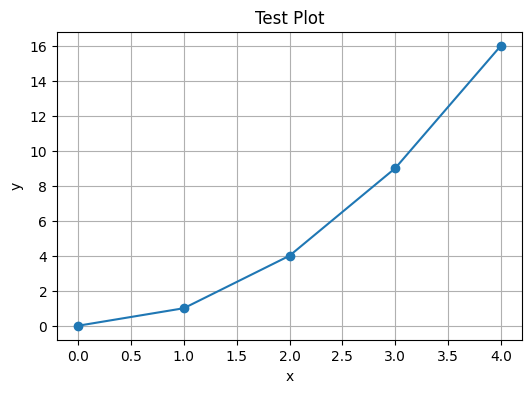

In [87]:
x = [0, 1, 2, 3, 4]
y = [0, 1, 4, 9, 16]

# Plot
plt.figure(figsize=(6, 4))
plt.plot(x, y, marker='o')
plt.title("Test Plot")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

In [88]:
# Define file paths
train_path = r"C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project\data\Processed_data\FR\train.csv"
test_path = r"C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project\data\Processed_data\FR\test.csv"
dev_path = r"C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project\data\Processed_data\FR\dev.csv"

# Load the datasets
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
dev_df = pd.read_csv(dev_path)

# train_df = train_df.reset_index()[["Time", "EUR/MWh"]]
# test_df = test_df.reset_index()[["Time", "EUR/MWh"]]
# dev_df = dev_df.reset_index()[["Time", "EUR/MWh"]]

# Get number of rows in each dataset
n_train = len(train_df)
n_test = len(test_df)
n_dev = len(dev_df)
n_total = n_train + n_test + n_dev

# Display shapes and percentages
print(f"Train set shape: {train_df.shape} → {100 * n_train / n_total:.2f}% of total data")
print(f"Test set shape:  {test_df.shape} → {100 * n_test / n_total:.2f}% of total data")
print(f"Dev set shape:   {dev_df.shape} → {100 * n_dev / n_total:.2f}% of total data")


# Optionally preview the first few rows
train_df.head()


Train set shape: (35060, 8) → 66.65% of total data
Test set shape:  (8759, 8) → 16.65% of total data
Dev set shape:   (8783, 8) → 16.70% of total data


,Time,Year,Month,Day,Hour,Timezone,EUR/MWh,date
0,2019-10-01 00:00:00+02:00,2019,10,1,0,+02:00,33.09,2019-10-01
1,2019-10-01 01:00:00+02:00,2019,10,1,1,+02:00,27.72,2019-10-01
2,2019-10-01 02:00:00+02:00,2019,10,1,2,+02:00,23.12,2019-10-01
3,2019-10-01 03:00:00+02:00,2019,10,1,3,+02:00,16.46,2019-10-01
4,2019-10-01 04:00:00+02:00,2019,10,1,4,+02:00,15.66,2019-10-01


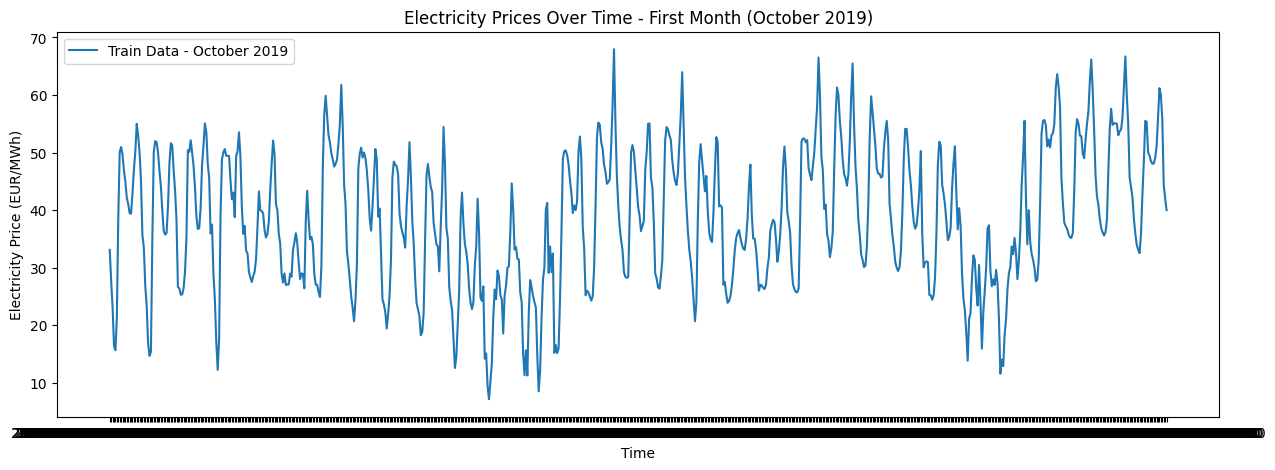

In [89]:
# Filter the first month (October 2019)
first_month = train_df[(train_df["Time"] >= "2019-10-01") & (train_df["Time"] < "2019-11-01")]

# Plot the first month
plt.figure(figsize=(15, 5))
plt.plot(first_month["Time"], first_month["EUR/MWh"], label="Train Data - October 2019", linewidth=1.5)
plt.xlabel("Time")
plt.ylabel("Electricity Price (EUR/MWh)")
plt.title("Electricity Prices Over Time - First Month (October 2019)")
plt.legend()
plt.grid(False)
plt.show()

Accuracy metric:
$$1- relative \ error$$

What relative error ? 
- Mean absolute ? 
- Sqared ? 

Relative to what? 
- mediane? mean ? 
- h-1 ? 
- j-7



In [90]:

def error_metric(y_true, y_pred, shift=24*7, L1=True, Median = False): #
    """
    Compute relative Mean Absolute Error (rMAE)
    comparing model prediction with 1 baseline:
    y_hat_naive(t) = y_true(t - 24h)
    """
    
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    
    
    y_true_adj = y_true[shift:]
    y_pred_adj = y_pred[shift:]
    y_naive = y_true[:-shift]  # yesterday's value

    # Compute errors
    if L1:
        if not Median:
            mae_model = np.mean(np.abs(y_true_adj - y_pred_adj))
            mae_naive = np.mean(np.abs(y_true_adj - y_naive))
            
            return mae_model / mae_naive
        
        if Median:
            median = np.median(y_naive)
            mae_model = np.mean(np.abs(y_true_adj - y_pred_adj))
            mae_naive = np.mean(np.abs(y_true_adj - median))
            
            return mae_model / mae_naive
    else:
        if not Median:
            mae_model = np.mean(np.sqrt((y_true_adj - y_pred_adj)**2))
            mae_naive = np.mean(np.sqrt((y_true_adj - y_naive)**2))
            
            return mae_model / mae_naive
        
        if Median:
            median = np.mean(y_naive)
            mae_model = np.mean(np.sqrt((y_true_adj - y_pred_adj)**2))
            mae_naive = np.mean(np.sqrt((y_true_adj - median)**2))
            
            return mae_model / mae_naive

        



In [91]:
import numpy as np

eps = 1e-8  # pour éviter la division par zéro

# --- Préparer les séries ---
train_series = train_df["EUR/MWh"].values.reshape(-1,1)
dev_series = dev_df["EUR/MWh"].values.reshape(-1,1)
test_series = test_df["EUR/MWh"].values.reshape(-1,1)

# --- Calculer moyenne et écart type sur le train set ---
mu = train_series.mean()
sigma = train_series.std()

# --- Normalisation gaussienne ---
train_scaled = (train_series - mu) / (sigma + eps)
dev_scaled = (dev_series - mu) / (sigma + eps)
test_scaled = (test_series - mu) / (sigma + eps)

# --- Créer les sliding windows ---
window_size = 24*7

def create_windows(series, window_size):
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i:i+window_size].flatten())
        y.append(series[i+window_size])
    return np.array(X), np.array(y)

X_train, y_train = create_windows(train_scaled, window_size)
X_dev, y_dev     = create_windows(dev_scaled, window_size)
X_test, y_test   = create_windows(test_scaled, window_size)

Prediction naive : h-1 = y hat

In [11]:
y_pred_train_naive = X_train[:, -1].reshape(-1, 1)
y_pred_dev_naive   = X_dev[:, -1].reshape(-1, 1)
y_pred_test_naive  = X_test[:, -1].reshape(-1, 1)



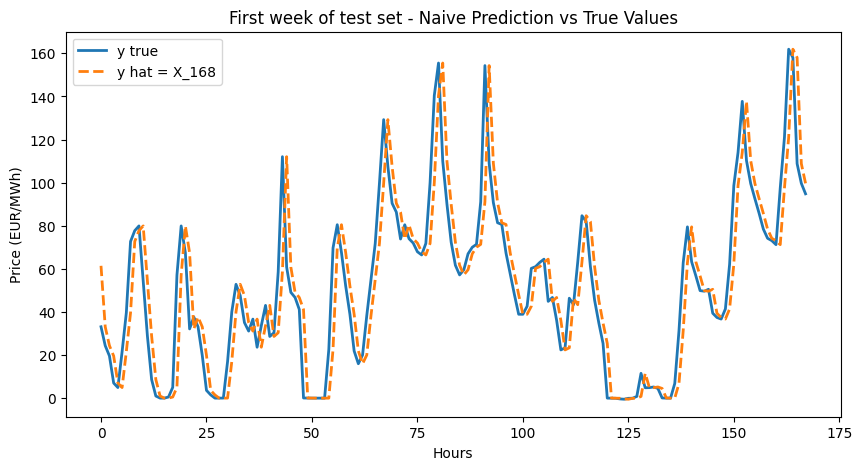

In [ ]:
# Nombre d'heures dans une semaine
hours_in_week = 24 * 7

# Prédiction naïve
y_test_pred = X_test[:, -1].reshape(-1, 1)

# Sélection de la première semaine
y_true_week = y_test[:hours_in_week].flatten()
y_pred_week = y_test_pred[:hours_in_week].flatten()

y_true_week_plot= y_true_week*sigma + mu
y_pred_week_plot= y_pred_week*sigma + mu

# Plot
plt.figure(figsize=(10,5))
plt.plot(y_true_week_plot, label="y true", linewidth=2)
plt.plot(y_pred_week_plot, label="y hat = X_168", linestyle='--', linewidth=2)
plt.title("First week of test set - Naive Prediction vs True Values")
plt.xlabel("Hours")
plt.ylabel("Price (EUR/MWh)")
plt.legend()
plt.grid(False)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error

def denorm(x_norm, mu, sigma, eps=1e-8):
    return x_norm * (sigma + eps) + mu
# --- Denormalisation ---
y_train_real = denorm(y_train, mu, sigma)
y_dev_real   = denorm(y_dev, mu, sigma)
y_test_real  = denorm(y_test, mu, sigma)

y_pred_train_real = denorm(y_pred_train_naive, mu, sigma)
y_pred_dev_real   = denorm(y_pred_dev_naive, mu, sigma)
y_pred_test_real  = denorm(y_pred_test_naive, mu, sigma)


mae_train_real = mean_absolute_error(y_train_real, y_pred_train_real)
mae_dev_real   = mean_absolute_error(y_dev_real, y_pred_dev_real)
mae_test_real  = mean_absolute_error(y_test_real, y_pred_test_real)

print("MAE (EUR/MWh)")
print(f"Train: {mae_train_real:.3f}")
print(f"Dev:   {mae_dev_real:.3f}")
print(f"Test:  {mae_test_real:.3f}")
print('\n')

L1=True
shift=24*7
Median=True
score_train_naive= error_metric(y_train, y_pred_train_naive, L1=L1, shift=shift, Median=Median)
score_dev_naive = error_metric(y_dev, y_pred_dev_naive, L1=L1, shift=shift, Median=Median)
score_test_naive = error_metric(y_test, y_pred_test_naive, L1=L1, shift=shift, Median=Median)
print('Accurancy: L1, median')
print(f"Relative MAE Train: {1-score_train_naive:.3f}")
print(f"Relative MAE Dev: {1-score_dev_naive:.3f}")
print(f"Relative MAE Test: {1-score_test_naive:.3f}")
print('\n')

L1=True
shift=24
Median=False 
score_train_naive= error_metric(y_train, y_pred_train_naive, L1=L1, shift=shift, Median=Median)
score_dev_naive = error_metric(y_dev, y_pred_dev_naive, L1=L1, shift=shift, Median=Median)
score_test_naive = error_metric(y_test, y_pred_test_naive, L1=L1, shift=shift, Median=Median)
print('Accurancy: L1, -24')
print(f"Relative MAE Train: {1-score_train_naive:.3f}")
print(f"Relative MAE Dev: {1-score_dev_naive:.3f}")
print(f"Relative MAE Test: {1-score_test_naive:.3f}")
print('\n')

L1=True
shift=24*7
Median=False 
score_train_naive= error_metric(y_train, y_pred_train_naive, L1=L1, shift=shift, Median=Median)
score_dev_naive = error_metric(y_dev, y_pred_dev_naive, L1=L1, shift=shift, Median=Median)
score_test_naive = error_metric(y_test, y_pred_test_naive, L1=L1, shift=shift, Median=Median)
print('Accurancy: L1, -168')
print(f"Relative MAE Train: {1-score_train_naive:.3f}")
print(f"Relative MAE Dev: {1-score_dev_naive:.3f}")
print(f"Relative MAE Test: {1-score_test_naive:.3f}")
print('\n')

MAE (EUR/MWh)
Train: 10.697
Dev:   9.370
Test:  11.274


Accurancy: L1, median
Relative MAE Train: 0.875
Relative MAE Dev: 0.717
Relative MAE Test: 0.732


Accurancy: L1, -24
Relative MAE Train: 0.536
Relative MAE Dev: 0.543
Relative MAE Test: 0.475


Accurancy: L1, -168
Relative MAE Train: 0.672
Relative MAE Dev: 0.663
Relative MAE Test: 0.650




Model 1: 1 layer, 1 neuron MSE

In [26]:
model = Sequential([Dense(1, input_shape=(window_size,), activation='linear')])
model.compile(optimizer='adam', loss='mse')

# Train model with explicit validation data
history_1 = model.fit(X_train, y_train, 
                    epochs=50, batch_size=64,
                    validation_data=(X_dev, y_dev))

Epoch 1/50
546/546 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.2188 - val_loss: 0.0352
Epoch 2/50
546/546 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 0.1023 - val_loss: 0.0218
Epoch 3/50
546/546 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.0772 - val_loss: 0.0163
Epoch 4/50
546/546 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0645 - val_loss: 0.0191
Epoch 5/50
546/546 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0566 - val_loss: 0.0144
Epoch 6/50
546/546 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0509 - val_loss: 0.0111
Epoch 7/50
546/546 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.0483 - val_loss: 0.0112
Epoch 8/50
546/546 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.0453 - val_loss: 0.0096
Epoch 9/50
546/546 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - loss: 0.0433 - val_loss: 0.0107
Epoch 10/50
546/546 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0413 - val_loss: 0.0100
Epoch 11/50
546/546 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 0.0395 - val_loss: 0.0085
Epoch 12/50
546/546 ━━━━━━━━━━━━━━━━━━━━ 

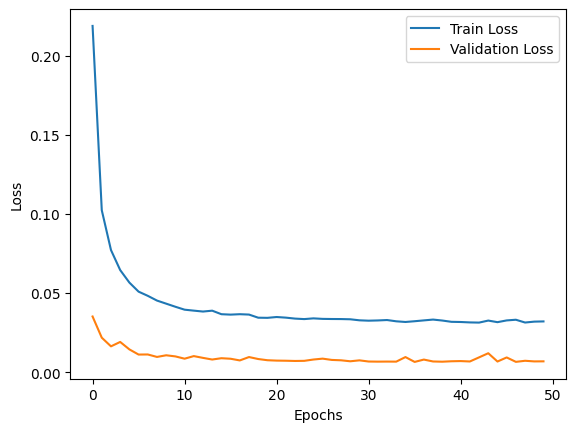

In [27]:
#plot la loss
plt.plot(history_1.history['loss'], label='Train Loss')
plt.plot(history_1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

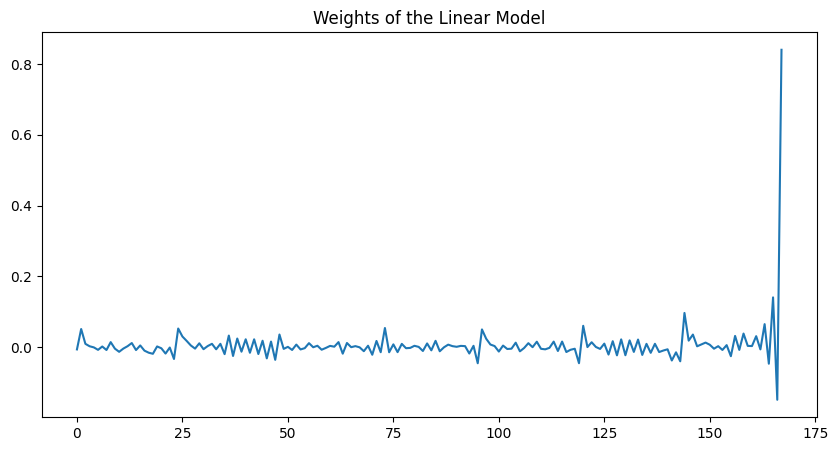

In [28]:
weights, bias = model.layers[0].get_weights()

#plot the weights
plt.figure(figsize=(10, 5))
plt.plot(weights.flatten())
plt.title("Weights of the Linear Model")
plt.show()

In [40]:
print(f"Nombre total de poids : {len(weights.flatten()):.3e}")
print(f"Moyenne (hors dernier élément) : {np.mean(weights.flatten()[:-1]):.3e}")
print(f"Variance (hors dernier élément) : {np.sqrt(np.var(weights.flatten()[:-1])):.3e}")
print(weights.flatten()[-1])

Nombre total de poids : 1.680e+02
Moyenne (hors dernier élément) : 1.153e-03
Variance (hors dernier élément) : 2.566e-02
0.84052944


In [41]:
# Predict on dev set
y_pred_train_1 = model.predict(X_train)
y_pred_dev_1 = model.predict(X_dev)
y_pred_test_1 = model.predict(X_test)

1091/1091 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step
270/270 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


In [44]:
from sklearn.metrics import mean_absolute_error

def denorm(x_norm, mu, sigma, eps=1e-8):
    return x_norm * (sigma + eps) + mu

# --- Denormalisation ---
y_train_real = denorm(y_train, mu, sigma)
y_dev_real   = denorm(y_dev, mu, sigma)
y_test_real  = denorm(y_test, mu, sigma)

y_pred_train_real = denorm(y_pred_train_1, mu, sigma)
y_pred_dev_real   = denorm(y_pred_dev_1, mu, sigma)
y_pred_test_real  = denorm(y_pred_test_1, mu, sigma)

In [45]:


mae_train_real = mean_absolute_error(y_train_real, y_pred_train_real)
mae_dev_real   = mean_absolute_error(y_dev_real, y_pred_dev_real)
mae_test_real  = mean_absolute_error(y_test_real, y_pred_test_real)

print("MAE (EUR/MWh)")
print(f"Train: {mae_train_real:.3f}")
print(f"Dev:   {mae_dev_real:.3f}")
print(f"Test:  {mae_test_real:.3f}")
print('\n')

L1=True
shift=24*7
Median=True
score_train_1 = error_metric(y_train, y_pred_train_1, L1=L1, shift=shift, Median=Median)
score_dev_1   = error_metric(y_dev, y_pred_dev_1, L1=L1, shift=shift, Median=Median)
score_test_1  = error_metric(y_test, y_pred_test_1, L1=L1, shift=shift, Median=Median)
print('Accuracy: L1, median')
print(f"Relative MAE Train: {1-score_train_1:.3f}")
print(f"Relative MAE Dev: {1-score_dev_1:.3f}")
print(f"Relative MAE Test: {1-score_test_1:.3f}")
print('\n')

L1=True
shift=24
Median=False 
score_train_1 = error_metric(y_train, y_pred_train_1, L1=L1, shift=shift, Median=Median)
score_dev_1   = error_metric(y_dev, y_pred_dev_1, L1=L1, shift=shift, Median=Median)
score_test_1  = error_metric(y_test, y_pred_test_1, L1=L1, shift=shift, Median=Median)
print('Accuracy: L1, -24')
print(f"Relative MAE Train: {1-score_train_1:.3f}")
print(f"Relative MAE Dev: {1-score_dev_1:.3f}")
print(f"Relative MAE Test: {1-score_test_1:.3f}")
print('\n')

L1=True
shift=24*7
Median=False 
score_train_1 = error_metric(y_train, y_pred_train_1, L1=L1, shift=shift, Median=Median)
score_dev_1   = error_metric(y_dev, y_pred_dev_1, L1=L1, shift=shift, Median=Median)
score_test_1  = error_metric(y_test, y_pred_test_1, L1=L1, shift=shift, Median=Median)
print('Accuracy: L1, -168')
print(f"Relative MAE Train: {1-score_train_1:.3f}")
print(f"Relative MAE Dev: {1-score_dev_1:.3f}")
print(f"Relative MAE Test: {1-score_test_1:.3f}")
print('\n')


MAE (EUR/MWh)
Train: 8.798
Dev:   7.640
Test:  8.745


Accuracy: L1, median
Relative MAE Train: 0.897
Relative MAE Dev: 0.769
Relative MAE Test: 0.792


Accuracy: L1, -24
Relative MAE Train: 0.618
Relative MAE Dev: 0.627
Relative MAE Test: 0.593


Accuracy: L1, -168
Relative MAE Train: 0.731
Relative MAE Dev: 0.725
Relative MAE Test: 0.728




We keep know L1  and Median, so that the denominator don't fluactuate too much with respect of the different sets

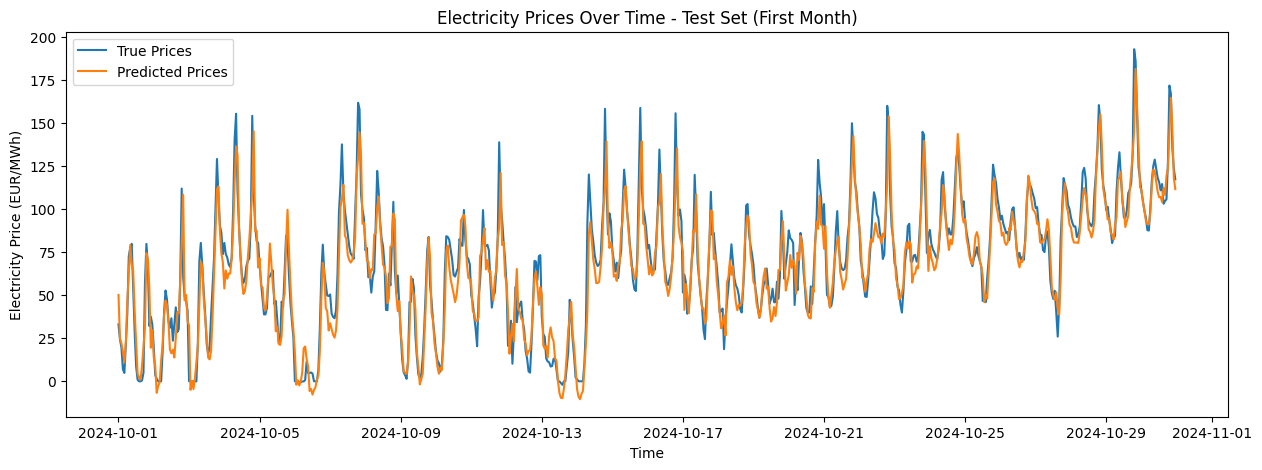

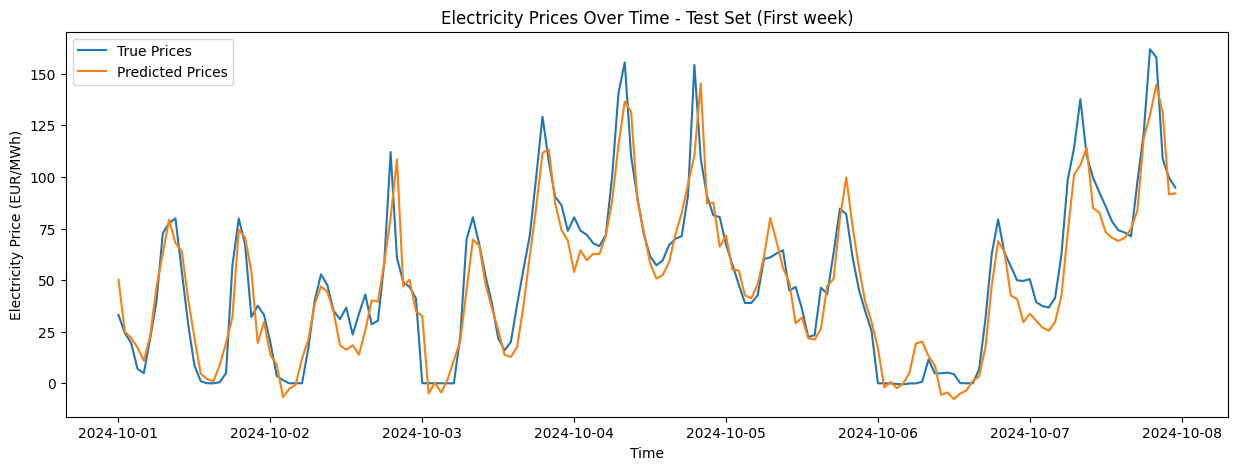

In [49]:
y_test_real
y_pred_test_real

# Plot one month (24h * 30)
plt.figure(figsize=(15, 5))
plt.plot(
    test_df["Time"].iloc[window_size:window_size + 24*30],
    y_true_inv[:24*30],
    label="True Prices", linewidth=1.5
)
plt.plot(
    test_df["Time"].iloc[window_size:window_size + 24*30],
    y_pred_inv[:24*30],
    label="Predicted Prices", linewidth=1.5
)
plt.xlabel("Time")
plt.ylabel("Electricity Price (EUR/MWh)")
plt.title("Electricity Prices Over Time - Test Set (First Month)")
plt.legend()
plt.grid(False)
plt.show()

# Plot one month (24h * 7)
plt.figure(figsize=(15, 5))
plt.plot(
    test_df["Time"].iloc[window_size:window_size + 24*7],
    y_true_inv[:24*7],
    label="True Prices", linewidth=1.5
)
plt.plot(
    test_df["Time"].iloc[window_size:window_size + 24*7],
    y_pred_inv[:24*7],
    label="Predicted Prices", linewidth=1.5
)
plt.xlabel("Time")
plt.ylabel("Electricity Price (EUR/MWh)")
plt.title("Electricity Prices Over Time - Test Set (First week)")
plt.legend()
plt.grid(False)
plt.show()

Model 1 layer 1 neuron Mae

In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model_mae = Sequential([
    Dense(1, input_shape=(window_size,), activation='linear')
])
model_mae.compile(optimizer='adam', loss='mae')

history_1_mae = model_mae.fit(
    X_train, y_train, 
    epochs=50, batch_size=64,
    validation_data=(X_dev, y_dev)
)

Epoch 1/50


c:\Users\pierr\anaconda3\envs\CS230\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


546/546 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.2383 - val_loss: 0.1235
Epoch 2/50
546/546 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.1274 - val_loss: 0.0969
Epoch 3/50
546/546 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.1062 - val_loss: 0.0851
Epoch 4/50
546/546 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0946 - val_loss: 0.0773
Epoch 5/50
546/546 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0876 - val_loss: 0.0788
Epoch 6/50
546/546 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0828 - val_loss: 0.0794
Epoch 7/50
546/546 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0786 - val_loss: 0.0754
Epoch 8/50
546/546 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0767 - val_loss: 0.0639
Epoch 9/50
546/546 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0731 - val_loss: 0.0849
Epoch 10/50
546/546 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0722 - val_loss: 0.0605
Epoch 11/50
546/546 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.0701 - val_loss: 0.0595
Epoch 12/50
546/546 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - lo

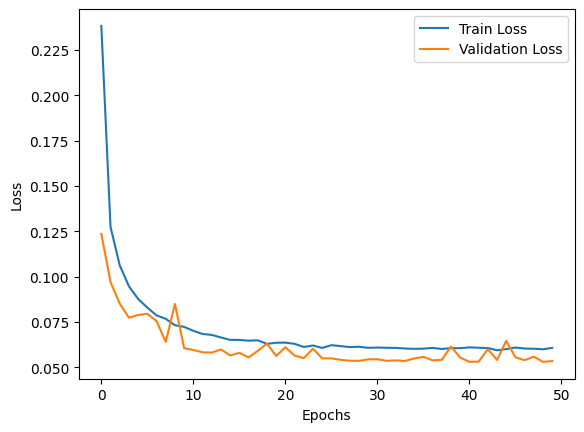

In [66]:
#plot la loss
plt.plot(history_1_mae.history['loss'], label='Train Loss')
plt.plot(history_1_mae.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

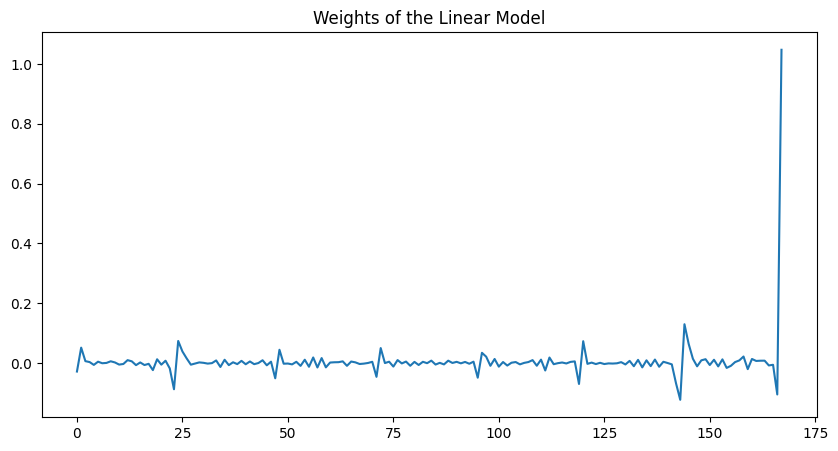

In [67]:
weights, bias = model_mae.layers[0].get_weights()

#plot the weights
plt.figure(figsize=(10, 5))
plt.plot(weights.flatten())
plt.title("Weights of the Linear Model")
plt.show()

In [68]:
print(f"Nombre total de poids : {len(weights.flatten()):.3e}")
print(f"Moyenne (hors dernier élément) : {np.mean(weights.flatten()[:-1]):.3e}")
print(f"Variance (hors dernier élément) : {np.sqrt(np.var(weights.flatten()[:-1])):.3e}")
print(weights.flatten()[-1])

Nombre total de poids : 1.680e+02
Moyenne (hors dernier élément) : -1.957e-04
Variance (hors dernier élément) : 2.494e-02
1.047701


In [69]:
# Predict on dev set
y_pred_train_1_mae = model_mae.predict(X_train)
y_pred_dev_1_mae = model_mae.predict(X_dev)
y_pred_test_1_mae = model_mae.predict(X_test)

1091/1091 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [71]:
y_pred_train_real_mae = denorm(y_pred_train_1_mae, mu, sigma)
y_pred_dev_real_mae   = denorm(y_pred_dev_1_mae, mu, sigma)
y_pred_test_real_mae  = denorm(y_pred_test_1_mae, mu, sigma)

In [73]:
mae_train_real = mean_absolute_error(y_train_real, y_pred_train_real_mae)
mae_dev_real   = mean_absolute_error(y_dev_real, y_pred_dev_real_mae)
mae_test_real  = mean_absolute_error(y_test_real, y_pred_test_real_mae)

print("MAE (EUR/MWh)")
print(f"Train: {mae_train_real:.3f}")
print(f"Dev:   {mae_dev_real:.3f}")
print(f"Test:  {mae_test_real:.3f}")
print('\n')

L1=True
shift=24*7
Median=True
score_train_1 = error_metric(y_train, y_pred_train_1_mae, L1=L1, shift=shift, Median=Median)
score_dev_1   = error_metric(y_dev, y_pred_dev_1_mae, L1=L1, shift=shift, Median=Median)
score_test_1  = error_metric(y_test, y_pred_test_1_mae, L1=L1, shift=shift, Median=Median)
print('Accuracy: L1, median')
print(f"Relative MAE Train: {1-score_train_1:.3f}")
print(f"Relative MAE Dev: {1-score_dev_1:.3f}")
print(f"Relative MAE Test: {1-score_test_1:.3f}")
print('\n')

L1=True
shift=24
Median=False 
score_train_1 = error_metric(y_train, y_pred_train_1_mae, L1=L1, shift=shift, Median=Median)
score_dev_1   = error_metric(y_dev, y_pred_dev_1_mae, L1=L1, shift=shift, Median=Median)
score_test_1  = error_metric(y_test, y_pred_test_1_mae, L1=L1, shift=shift, Median=Median)
print('Accuracy: L1, -24')
print(f"Relative MAE Train: {1-score_train_1:.3f}")
print(f"Relative MAE Dev: {1-score_dev_1:.3f}")
print(f"Relative MAE Test: {1-score_test_1:.3f}")
print('\n')

L1=True
shift=24*7
Median=False 
score_train_1 = error_metric(y_train, y_pred_train_1_mae, L1=L1, shift=shift, Median=Median)
score_dev_1   = error_metric(y_dev, y_pred_dev_1_mae, L1=L1, shift=shift, Median=Median)
score_test_1  = error_metric(y_test, y_pred_test_1_mae, L1=L1, shift=shift, Median=Median)
print('Accuracy: L1, -168')
print(f"Relative MAE Train: {1-score_train_1:.3f}")
print(f"Relative MAE Dev: {1-score_dev_1:.3f}")
print(f"Relative MAE Test: {1-score_test_1:.3f}")
print('\n')


MAE (EUR/MWh)
Train: 7.378
Dev:   6.748
Test:  7.865


Accuracy: L1, median
Relative MAE Train: 0.914
Relative MAE Dev: 0.796
Relative MAE Test: 0.813


Accuracy: L1, -24
Relative MAE Train: 0.680
Relative MAE Dev: 0.671
Relative MAE Test: 0.634


Accuracy: L1, -168
Relative MAE Train: 0.774
Relative MAE Dev: 0.757
Relative MAE Test: 0.755




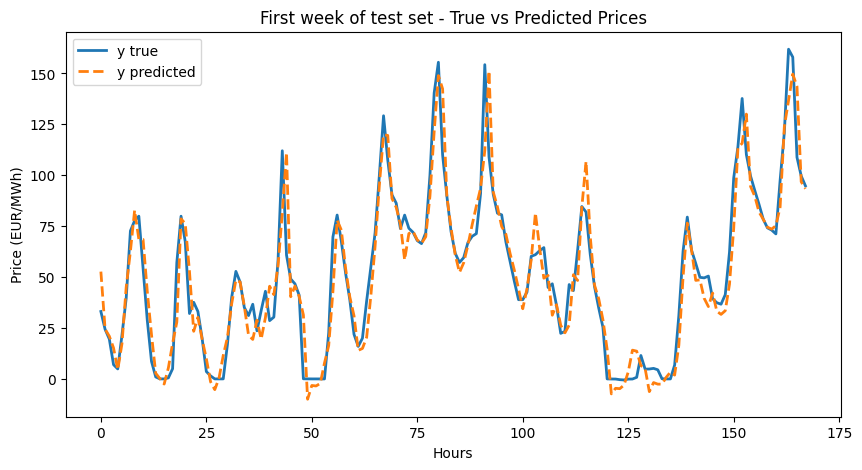

In [83]:
import matplotlib.pyplot as plt

# Nombre d'heures dans une semaine
hours_in_week = 24 * 7

# Sélection de la première semaine
y_true_week = y_test_real[:hours_in_week].flatten()
y_pred_week = y_pred_test_real_mae[:hours_in_week].flatten()

# Plot
plt.figure(figsize=(10,5))
plt.plot(y_true_week, label="y true", linewidth=2)
plt.plot(y_pred_week, label="y predicted", linestyle='--', linewidth=2)
plt.title("First week of test set - True vs Predicted Prices")
plt.xlabel("Hours")
plt.ylabel("Price (EUR/MWh)")
plt.legend()
plt.grid(False)
plt.show()


Model 2: 

In [92]:


model2 = Sequential([
    Dense(168, input_shape=(window_size,), activation='relu'),
    Dense(48, activation='relu'),
    Dense(24, activation='relu'),
    Dense(1, activation='linear'),
])

model2.compile(optimizer='adam', loss='mae')

# Entraînement avec validation explicite
history_2 = model2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_dev, y_dev)
)


Epoch 1/50


c:\Users\pierr\anaconda3\envs\CS230\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1091/1091 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - loss: 0.1254 - val_loss: 0.0961
Epoch 2/50
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - loss: 0.0901 - val_loss: 0.0745
Epoch 3/50
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - loss: 0.0809 - val_loss: 0.0704
Epoch 4/50
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - loss: 0.0767 - val_loss: 0.0662
Epoch 5/50
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 36s 16ms/step - loss: 0.0754 - val_loss: 0.0626
Epoch 6/50
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - loss: 0.0710 - val_loss: 0.0640
Epoch 7/50
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 0.0689 - val_loss: 0.0611
Epoch 8/50
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 0.0680 - val_loss: 0.0618
Epoch 9/50
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 0.0674 - val_loss: 0.0816
Epoch 10/50
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 37s 34ms/step - loss: 0.0675 - val_loss: 0.0612
Epoch 11/50
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 44s 40ms/step - loss: 0.0664 - val_loss: 0.0616
Epoch 12/50
1091/10

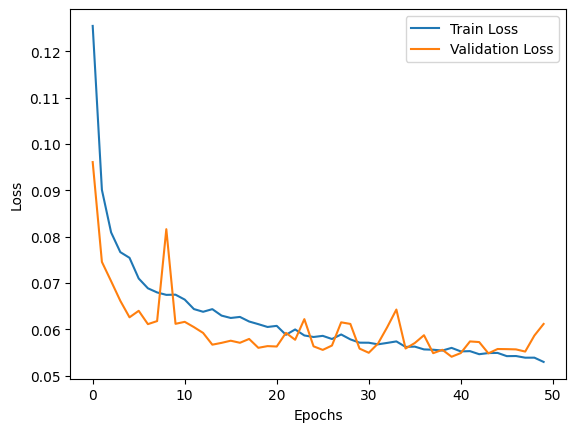

In [93]:
#plot la loss
plt.plot(history_2.history['loss'], label='Train Loss')
plt.plot(history_2.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [96]:
y_pred_train = model2.predict(X_train)
y_pred_dev = model2.predict(X_dev)
y_pred_test = model2.predict(X_test)


1091/1091 ━━━━━━━━━━━━━━━━━━━━ 1s 981us/step
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [ ]:
y_pred_train_real = denorm(y_pred_train_1_mae, mu, sigma)
y_pred_dev_real   = denorm(y_pred_dev_1_mae, mu, sigma)
y_pred_test_real  = denorm(y_pred_test_1_mae, mu, sigma)

In [101]:
mae_train_real = mean_absolute_error(y_train_real, y_pred_train_real)
mae_dev_real   = mean_absolute_error(y_dev_real, y_pred_dev_real)
mae_test_real  = mean_absolute_error(y_test_real, y_pred_test_real)

print("MAE (EUR/MWh)")
print(f"Train: {mae_train_real:.3f}")
print(f"Dev:   {mae_dev_real:.3f}")
print(f"Test:  {mae_test_real:.3f}")
print('\n')

L1=True
shift=24*7
Median=True
score_train_1 = error_metric(y_train, y_pred_train, L1=L1, shift=shift, Median=Median)
score_dev_1   = error_metric(y_dev, y_pred_dev, L1=L1, shift=shift, Median=Median)
score_test_1  = error_metric(y_test, y_pred_test, L1=L1, shift=shift, Median=Median)
print('Accuracy: L1, median')
print(f"Relative MAE Train: {1-score_train_1:.3f}")
print(f"Relative MAE Dev: {1-score_dev_1:.3f}")
print(f"Relative MAE Test: {1-score_test_1:.3f}")
print('\n')

L1=True
shift=24
Median=False 
score_train_1 = error_metric(y_train, y_pred_train, L1=L1, shift=shift, Median=Median)
score_dev_1   = error_metric(y_dev, y_pred_dev, L1=L1, shift=shift, Median=Median)
score_test_1  = error_metric(y_test, y_pred_test, L1=L1, shift=shift, Median=Median)
print('Accuracy: L1, -24')
print(f"Relative MAE Train: {1-score_train_1:.3f}")
print(f"Relative MAE Dev: {1-score_dev_1:.3f}")
print(f"Relative MAE Test: {1-score_test_1:.3f}")
print('\n')

L1=True
shift=24*7
Median=False 
score_train_1 = error_metric(y_train, y_pred_train, L1=L1, shift=shift, Median=Median)
score_dev_1   = error_metric(y_dev, y_pred_dev, L1=L1, shift=shift, Median=Median)
score_test_1  = error_metric(y_test, y_pred_test, L1=L1, shift=shift, Median=Median)
print('Accuracy: L1, -168')
print(f"Relative MAE Train: {1-score_train_1:.3f}")
print(f"Relative MAE Dev: {1-score_dev_1:.3f}")
print(f"Relative MAE Test: {1-score_test_1:.3f}")
print('\n')


MAE (EUR/MWh)
Train: 8.798
Dev:   7.640
Test:  8.745


Accuracy: L1, median
Relative MAE Train: 0.917
Relative MAE Dev: 0.765
Relative MAE Test: 0.794


Accuracy: L1, -24
Relative MAE Train: 0.693
Relative MAE Dev: 0.622
Relative MAE Test: 0.596


Accuracy: L1, -168
Relative MAE Train: 0.784
Relative MAE Dev: 0.720
Relative MAE Test: 0.730




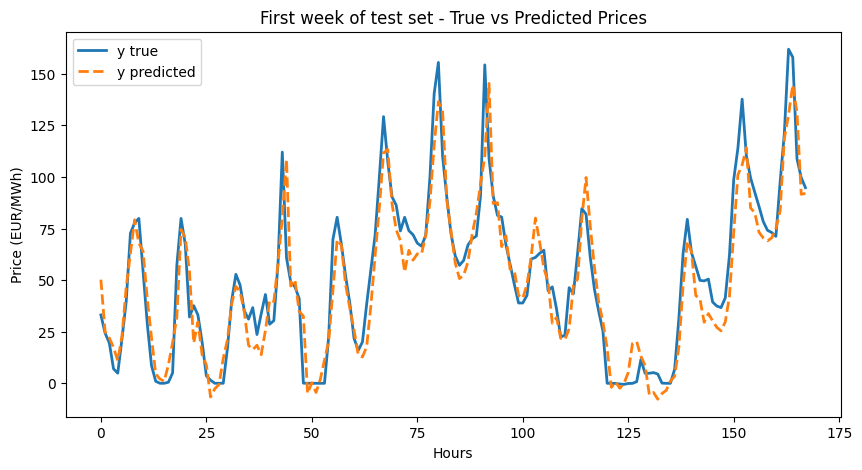

In [100]:
# Nombre d'heures dans une semaine
hours_in_week = 24 * 7

# Sélection de la première semaine
y_true_week = y_test_real[:hours_in_week].flatten()
y_pred_week = y_pred_test_real[:hours_in_week].flatten()

# Plot
plt.figure(figsize=(10,5))
plt.plot(y_true_week, label="y true", linewidth=2)
plt.plot(y_pred_week, label="y predicted", linestyle='--', linewidth=2)
plt.title("First week of test set - True vs Predicted Prices")
plt.xlabel("Hours")
plt.ylabel("Price (EUR/MWh)")
plt.legend()
plt.grid(False)
plt.show()

Model 3: Addition of exogeneous data

In [51]:
import pandas as pd
import numpy as np

# -------------------------
# 1. Define file paths
# -------------------------
train_path = r"C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project\data\Processed_data\FR\train.csv"
dev_path   = r"C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project\data\Processed_data\FR\dev.csv"
test_path  = r"C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project\data\Processed_data\FR\test.csv"

load_path = r"C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project\data\FR_DAM_Load_Forecasts\FR_load_processed.csv"
ren_path  = r"C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project\data\FR_REN_DAM_Forecasts\FR_ren_processed.csv"

# -------------------------
# 2. Load datasets
# -------------------------
train_df = pd.read_csv(train_path, parse_dates=['Time'])
dev_df   = pd.read_csv(dev_path, parse_dates=['Time'])
test_df  = pd.read_csv(test_path, parse_dates=['Time'])

load_df = pd.read_csv(load_path, parse_dates=['Time'])
ren_df  = pd.read_csv(ren_path, parse_dates=['Time'])

# -------------------------
# 3. Preprocess load & EnR
# -------------------------
load_df = load_df[['Time', 'MW']]               # channel 1
ren_df['Total_REN'] = ren_df['Wind Onshore'] + ren_df['Solar']
ren_df = ren_df[['Time', 'Total_REN']]         # channel 2

# -------------------------
# 4. Merge datasets
# -------------------------
def merge_features(price_df):
    merged = price_df.merge(load_df, on='Time', how='left')
    merged = merged.merge(ren_df, on='Time', how='left')
    # Vérification NaN
    if merged.isna().sum().sum() > 0:
        print("Warning: NaN values found, filling with 0")
        merged = merged.fillna(0)
    # Construction X : shape (n_samples, n_channels)
    X = merged[['EUR/MWh', 'MW', 'Total_REN']].values
    # Reshape pour modèles type CNN1D ou RNN : (n_samples, n_channels, 1)
    X = X.reshape(X.shape[0], X.shape[1], 1)
    return X

X_train = merge_features(train_df)
X_dev   = merge_features(dev_df)
X_test  = merge_features(test_df)

# -------------------------
# 5. Vérification
# -------------------------
print("X_train shape:", X_train.shape)
print("X_dev shape:  ", X_dev.shape)
print("X_test shape: ", X_test.shape)


X_train shape: (35060, 3, 1)
X_dev shape:   (8783, 3, 1)
X_test shape:  (8759, 3, 1)


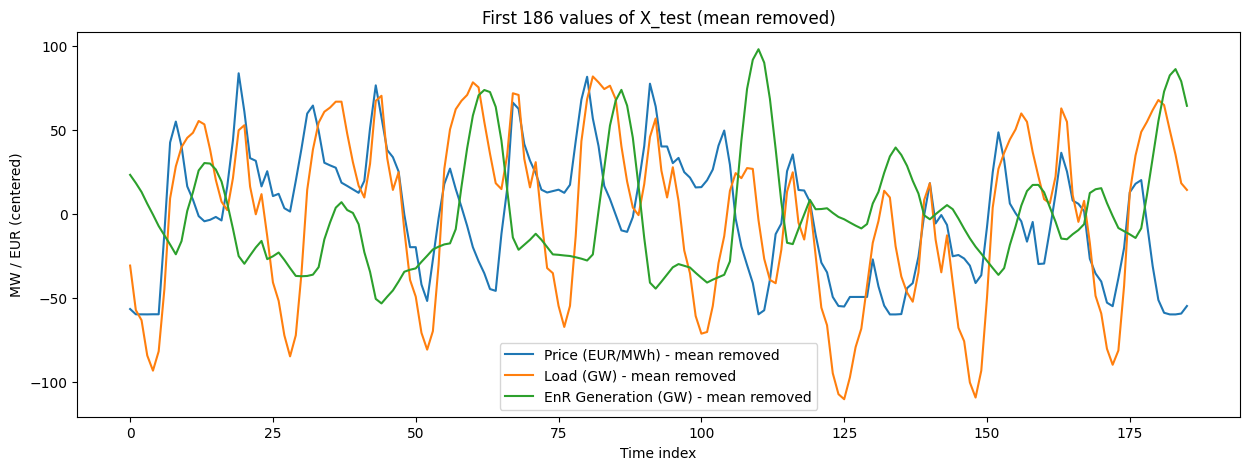

In [66]:
import matplotlib.pyplot as plt

# Nombre de points à afficher
n_points = 186

# Sélection des 186 premières valeurs
X_plot = X_test[:n_points, :, 0]

# Soustraire la moyenne de chaque channel
X_plot_centered = X_plot - X_plot.mean(axis=0)

# Plot
plt.figure(figsize=(15,5))
plt.plot(X_plot_centered[:,0], label='Price (EUR/MWh) - mean removed', linewidth=1.5)
plt.plot(X_plot_centered[:,1]/100, label='Load (GW) - mean removed', linewidth=1.5)
plt.plot(X_plot_centered[:,2]/100, label='EnR Generation (GW) - mean removed', linewidth=1.5)

plt.xlabel('Time index')
plt.ylabel('MW / EUR (centered)')
plt.title(f'First {n_points} values of X_test (mean removed)')
plt.legend()
plt.grid(False)
plt.show()


In [68]:
# -------------------------
# 1. On reprend X_train, X_dev, X_test du merge_features
# -------------------------
# X_train, X_dev, X_test ont shape (n_samples, n_channels, 1)
# On va transformer en (n_samples, n_channels) pour le scaler
X_train_flat = X_train[:,:,0]
X_dev_flat   = X_dev[:,:,0]
X_test_flat  = X_test[:,:,0]

# -------------------------
# 2. Scale chaque channel séparément
# -------------------------
scalers = {}
X_train_scaled = np.zeros_like(X_train_flat)
X_dev_scaled   = np.zeros_like(X_dev_flat)
X_test_scaled  = np.zeros_like(X_test_flat)

for i in range(X_train_flat.shape[1]):  # chaque channel
    scalers[i] = MinMaxScaler()
    X_train_scaled[:,i] = scalers[i].fit_transform(X_train_flat[:,i].reshape(-1,1)).flatten()
    X_dev_scaled[:,i]   = scalers[i].transform(X_dev_flat[:,i].reshape(-1,1)).flatten()
    X_test_scaled[:,i]  = scalers[i].transform(X_test_flat[:,i].reshape(-1,1)).flatten()

# -------------------------
# 3. Création des sliding windows
# -------------------------
window_size = 24*7  # 1 semaine

def create_sliding_windows(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size].flatten())  # aplati pour Dense/Conv1D simple
        y.append(data[i+window_size, 0])           # prédire uniquement le prix
    return np.array(X), np.array(y)

X_train_windows, y_train = create_sliding_windows(X_train_scaled, window_size)
X_dev_windows, y_dev     = create_sliding_windows(X_dev_scaled, window_size)
X_test_windows, y_test   = create_sliding_windows(X_test_scaled, window_size)

# -------------------------
# 4. Vérification
# -------------------------
print("X_train shape:", X_train_windows.shape, "y_train shape:", y_train.shape)
print("X_dev shape:  ", X_dev_windows.shape, "y_dev shape:", y_dev.shape)
print("X_test shape: ", X_test_windows.shape, "y_test shape:", y_test.shape)

X_train shape: (34892, 504) y_train shape: (34892,)
X_dev shape:   (8615, 504) y_dev shape: (8615,)
X_test shape:  (8591, 504) y_test shape: (8591,)


In [69]:


# -------------------------
# 1. On récupère les données fusionnées
# X_train, X_dev, X_test ont shape (n_samples, n_channels, 1)
# On transforme en (n_samples, n_channels)
# -------------------------
X_train_flat = X_train[:,:,0]
X_dev_flat   = X_dev[:,:,0]
X_test_flat  = X_test[:,:,0]

# -------------------------
# 2. Scale chaque channel séparément
# -------------------------
scalers = {}
X_train_scaled = np.zeros_like(X_train_flat)
X_dev_scaled   = np.zeros_like(X_dev_flat)
X_test_scaled  = np.zeros_like(X_test_flat)

for i in range(X_train_flat.shape[1]):  # chaque channel
    scalers[i] = MinMaxScaler()
    X_train_scaled[:,i] = scalers[i].fit_transform(X_train_flat[:,i].reshape(-1,1)).flatten()
    X_dev_scaled[:,i]   = scalers[i].transform(X_dev_flat[:,i].reshape(-1,1)).flatten()
    X_test_scaled[:,i]  = scalers[i].transform(X_test_flat[:,i].reshape(-1,1)).flatten()

# -------------------------
# 3. Création des sliding windows multicanal
# -------------------------
window_size = 24*7  # 1 semaine

def create_multichannel_windows(data, window_size):
    X, y = [], []
    n_channels = data.shape[1]
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size, :])  # conserve les 3 channels
        y.append(data[i+window_size, 0])    # prédire uniquement le prix
    return np.array(X), np.array(y)

X_train_windows, y_train = create_multichannel_windows(X_train_scaled, window_size)
X_dev_windows, y_dev     = create_multichannel_windows(X_dev_scaled, window_size)
X_test_windows, y_test   = create_multichannel_windows(X_test_scaled, window_size)

# -------------------------
# 4. Vérification des shapes
# -------------------------
print("X_train shape:", X_train_windows.shape)  # (n_samples, window_size, 3)
print("y_train shape:", y_train.shape)
print("X_dev shape:", X_dev_windows.shape)
print("y_dev shape:", y_dev.shape)
print("X_test shape:", X_test_windows.shape)
print("y_test shape:", y_test.shape)


X_train shape: (34892, 168, 3)
y_train shape: (34892,)
X_dev shape: (8615, 168, 3)
y_dev shape: (8615,)
X_test shape: (8591, 168, 3)
y_test shape: (8591,)


In [70]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten

In [71]:

# Taille de la fenêtre et nombre de channels
timesteps = X_train_windows.shape[1]  # window_size
n_channels = X_train_windows.shape[2] # 3 channels

# -------------------------
# Construction du modèle
# -------------------------
model = Sequential([
    Conv1D(filters=168, kernel_size=1, activation='relu', input_shape=(timesteps, n_channels)),
    Flatten(),             # aplatisse pour Dense
    Dense(1)               # prédiction du prix
])

# Compilation
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Vérification
model.summary()


c:\Users\pierr\anaconda3\envs\CS230\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 168, 168)       │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28224)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │        28,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,897 (112.88 KB)

 Trainable params: 28,897 (112.88 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
history_5 = model.fit(
    X_train_windows, y_train,
    validation_data=(X_dev_windows, y_dev),
    epochs=40,
    batch_size=32,
    verbose=1
)

Epoch 1/40
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 46s 42ms/step - loss: 1.4363e-04 - mae: 0.0067 - val_loss: 6.6666e-05 - val_mae: 0.0065
Epoch 2/40
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 35s 32ms/step - loss: 1.2698e-04 - mae: 0.0063 - val_loss: 1.1838e-04 - val_mae: 0.0089
Epoch 3/40
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 49s 39ms/step - loss: 9.8439e-05 - mae: 0.0054 - val_loss: 5.6368e-05 - val_mae: 0.0060
Epoch 4/40
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 78s 35ms/step - loss: 8.1138e-05 - mae: 0.0047 - val_loss: 5.7641e-05 - val_mae: 0.0063
Epoch 5/40
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 50s 46ms/step - loss: 7.9246e-05 - mae: 0.0046 - val_loss: 4.7586e-05 - val_mae: 0.0056
Epoch 6/40
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 36s 33ms/step - loss: 7.8620e-05 - mae: 0.0046 - val_loss: 3.3334e-05 - val_mae: 0.0045
Epoch 7/40
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 52s 47ms/step - loss: 7.1334e-05 - mae: 0.0042 - val_loss: 3.2608e-05 - val_mae: 0.0046
Epoch 8/40
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 50s 46ms/step - loss: 6.9925e-05 - mae: 0.0041 -

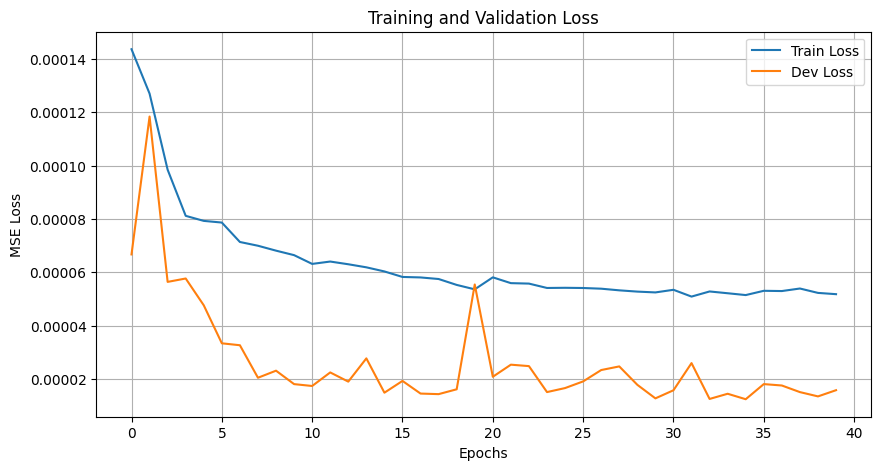

In [77]:
plt.figure(figsize=(10,5))
plt.plot(history_5.history['loss'], label='Train Loss')
plt.plot(history_5.history['val_loss'], label='Dev Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [79]:
y_pred_train = model.predict(X_train_windows)
y_pred_dev = model.predict(X_dev_windows)
y_pred_test = model.predict(X_test_windows)

1091/1091 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step
270/270 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step


In [81]:
# Compute error
score_train_conv= error_metric(y_train, y_pred_train)
score_dev_conv = error_metric(y_dev, y_pred_dev)
score_test_conv = error_metric(y_test, y_pred_test)
print('Accuracy:L1, j-7, Median')
print(f"Accuracy Train (Conv1D) : {1-score_train_conv:.3f}")
print(f"Accuracy Dev   (Conv1D) : {1-score_dev_conv:.3f}")
print(f"Accuracy Test  (Conv1D) : {1-score_test_conv:.3f}")

print('\nTo be compared to the 1-layer-1-neuron model:' )
print(f"Accuracy Train (1-neuron) : {1-score_train_1:.3f}")
print(f"Accuracy Dev   (1-neuron) : {1-score_dev_1:.3f}")
print(f"Accuracy Test  (1-neuron) : {1-score_test_1:.3f}")

print('\nGain in performance on test set:')
print(f'{(((1 - score_test_conv)-(1 - score_test_1)) / (1 - score_test_1)*100):.3f}%')


Accuracy:L1, j-7, Median
Accuracy Train (Conv1D) : 0.876
Accuracy Dev   (Conv1D) : 0.720
Accuracy Test  (Conv1D) : 0.750

To be compared to the 1-layer-1-neuron model:
Accuracy Train (1-neuron) : 0.874
Accuracy Dev   (1-neuron) : 0.734
Accuracy Test  (1-neuron) : 0.763

Gain in performance on test set:
-1.631%


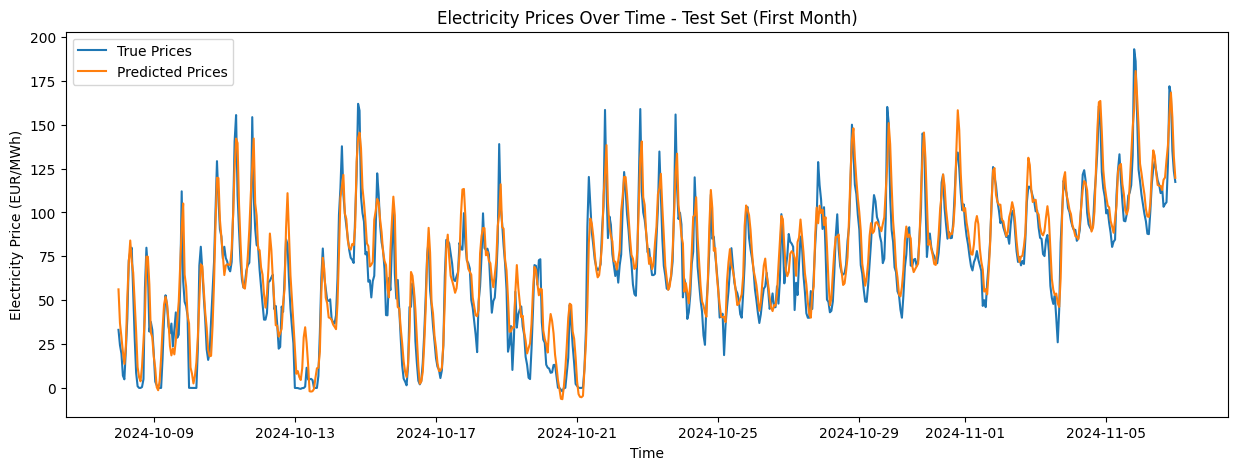

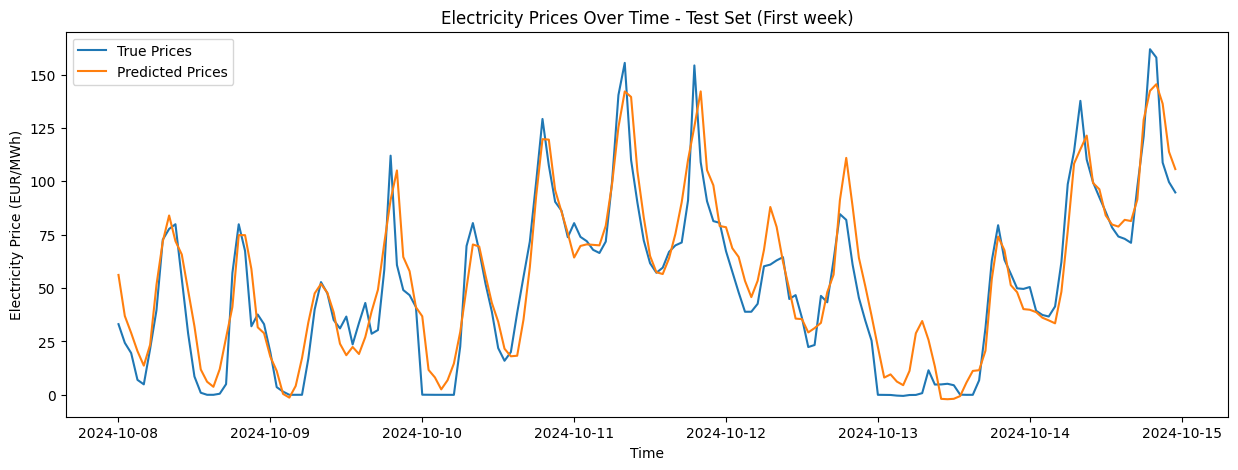

In [82]:
# Ensure y_test and y_pred_test are 2D
y_test = y_test.reshape(-1, 1)
y_pred_test = y_pred_test.reshape(-1, 1)

# Inverse transform predictions and true values
y_true_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred_test)

# Plot one month (24h * 30)
plt.figure(figsize=(15, 5))
plt.plot(
    test_df["Time"].iloc[window_size:window_size + 24*30],
    y_true_inv[:24*30],
    label="True Prices", linewidth=1.5
)
plt.plot(
    test_df["Time"].iloc[window_size:window_size + 24*30],
    y_pred_inv[:24*30],
    label="Predicted Prices", linewidth=1.5
)
plt.xlabel("Time")
plt.ylabel("Electricity Price (EUR/MWh)")
plt.title("Electricity Prices Over Time - Test Set (First Month)")
plt.legend()
plt.grid(False)
plt.show()

# Plot one month (24h * 7)
plt.figure(figsize=(15, 5))
plt.plot(
    test_df["Time"].iloc[window_size:window_size + 24*7],
    y_true_inv[:24*7],
    label="True Prices", linewidth=1.5
)
plt.plot(
    test_df["Time"].iloc[window_size:window_size + 24*7],
    y_pred_inv[:24*7],
    label="Predicted Prices", linewidth=1.5
)
plt.xlabel("Time")
plt.ylabel("Electricity Price (EUR/MWh)")
plt.title("Electricity Prices Over Time - Test Set (First week)")
plt.legend()
plt.grid(False)
plt.show()